# Compare models on MIMIC-III mortality (COPER vs transformer baseline)

Single codebase: `code/COPER`. Training entry point: `utils/run_exp.py` (choose architecture with `--model-type`).

## Shared front end (all runs in this notebook)

- Optional linear embedding of vitals, then (with `--cont-in`) a **Neural ODE** on the irregular timeline so the model sees a regular grid `(batch, seq_len, features)`.

## What differs: COPER / Perceiver vs `TRANSFORMER`

In this repo, **`COPER` and `PERCEIVER` both instantiate the same class** `COPER` in `src/coper_model.py`. The alternative baseline is **`TRANSFORMER`** in `src/transformer_model.py`.

| | **COPER** (`--model-type COPER`) | **Transformer baseline** (`--model-type TRANSFORMER`) |
|---|--------------------------------|--------------------------------------------------------|
| Bottleneck | Fixed learned **latent queries** `(num_latents, latent_dim)`; **cross-attention** latents→sequence, then **self-attention among latents** only | **No** latent bottleneck; first block is **self-attention over time** (Q,K,V from the sequence) |
| Cost scaling | Dominated by **num_latents × T** in cross-attention (often `num_latents ≪ T`) | Dominated by **T × T** per layer on the ODE grid |
| **`--second-node`** | Optional **second Neural ODE on the Perceiver latent grid** (2-NODE variant) | Optional **second Neural ODE on the sequence** after self-attention (same flag) |

**1-NODE vs 2-NODE**: toggle with `--second-node` for **both** COPER and TRANSFORMER. `run_exp.py` adds checkpoint suffix `_N2` for 2-NODE (e.g. `COPER-mimic-..._S1_N2.ckpt`, `TRANSFORMER-mimic-..._S1_N2.ckpt`).

Set `INCLUDE_TRANSFORMER_BASELINE` in the next cell to `False` if you only want the two COPER variants (faster).

## Outputs

Training writes checkpoints, logs, and `Predictions_*.npz` under `code/COPER/results/` (`--results-dir`). Checkpoints are exported to portable bundles (`.pt` + `.json`) via `utils/export_coper_checkpoint.py` (pass `--model-type` for correct metadata on the transformer run).

Export bundle names use **`_e{N}`** (e.g. `coper_1node_drop0.5_s1_e1.pt`). **`NITERS_LIST`** in the next cell must match **`NITERS_TO_VIS`** in `display_embeddings.ipynb` for the epochs you care about.

**Note:** If `NITERS_LIST` has **multiple** epoch counts, training runs them in order; `Predictions_*.npz` under `results/` match only the **last** `niters` in the list (unless you change `--results-dir` between runs).


In [9]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BENCH = Path('/home/charlesv/Desktop/StatisitcalGenetics/code/COPER').resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.benchmark_utils import (
    patch_paths_json,
    restore_paths_json,
    run_one,
)

In [10]:
# ---- Paths and benchmark config ----
ROOT = Path('/home/charlesv/Desktop/StatisitcalGenetics')
REPO = ROOT / 'code' / 'COPER'
assert REPO.is_dir(), f'Missing repo: {REPO}'

# Training outputs (checkpoints, logs, Predictions_*.npz) go under --results-dir (default: results/ in this repo)
BENCH = ROOT / 'code' / 'COPER'
RESULTS_ROOT = BENCH / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Optional full-sequence transformer baseline (O(T²) attention per layer — slower / more memory).
INCLUDE_TRANSFORMER_BASELINE = True

# (arch_id, human label, extra CLI tokens after BASE_SHARED_ARGS; each row sets --model-type)
ARCHITECTURES_CORE = [
    ('coper_1node', '1-NODE (ODE → Perceiver)', ['--model-type', 'COPER']),
    ('coper_2node', '2-NODE (ODE → Perceiver → ODE on latents)', ['--model-type', 'COPER', '--second-node']),
]
ARCHITECTURES_XFM = [
    (
        'transformer_baseline',
        'TRANSFORMER (ODE → T×T self-attention)',
        ['--model-type', 'TRANSFORMER'],
    ),
    (
        'transformer_2node',
        'TRANSFORMER 2-NODE (ODE → T×T self-attention → ODE on sequence)',
        ['--model-type', 'TRANSFORMER', '--second-node'],
    ),
]
ARCHITECTURES = ARCHITECTURES_CORE + (ARCHITECTURES_XFM if INCLUDE_TRANSFORMER_BASELINE else [])

FOLD = -1  # must match utils/run_exp default / your training setup (checkpoint name uses this)

MORTALITY_PICKLE = ROOT / 'MIMIC' / 'mimic3-benchmarks' / 'data' / 'mortality_for_coper.data'
assert MORTALITY_PICKLE.is_file(), f'Missing dataset file: {MORTALITY_PICKLE}'

# Smoke-test defaults. Increase for full benchmark.
SEEDS = [1]
DROPS = [0.50]  # drop ratio
# Train+export once per entry (each run uses --niters below). Quick test: [1] only; uncomment 3 and 10 for full comparison.
NITERS_LIST = [
    1,
    3,
    # 10,
]
BATCH_SIZE = 64
PATIENCE = 10

# Shared hyperparameters (same as run_irregular_mimic.sh); --model-type is per-architecture above; --niters comes from NITERS_LIST in the run loop.
BASE_SHARED_ARGS = [
    '--dataset', 'mimic',
    '--cont-in',
    '--self-per-cross-attn', '1',
    '--latent-heads', '2',
    '--cross-heads', '1',
    '--cross-dim-head', '128',
    '--latent-dim-head', '128',
    '--latent-dim', '64',
    '--units', '128',
    '--ode-dropout', '0.5',
    '--att-dropout', '0.5',
    '--ff-dropout', '0.5',
    '--num-latents', '48',
    '--batch-size', str(BATCH_SIZE),
    '--patience', str(PATIENCE),
    '--results-dir', str(RESULTS_ROOT.resolve()),
]

print('Repo:', REPO)
print('Results root:', RESULTS_ROOT)
print('Include transformer baseline:', INCLUDE_TRANSFORMER_BASELINE)
print('NITERS_LIST:', NITERS_LIST)
print('Architectures:', [a[0] for a in ARCHITECTURES])
print('Dataset:', MORTALITY_PICKLE)


Repo: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
Results root: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results
Include transformer baseline: True
NITERS_LIST: [1, 3]
Architectures: ['coper_1node', 'coper_2node', 'transformer_baseline', 'transformer_2node']
Dataset: /home/charlesv/Desktop/StatisitcalGenetics/MIMIC/mimic3-benchmarks/data/mortality_for_coper.data


In [11]:
# ---- Run benchmark grid (architectures × NITERS_LIST) ----
rows = []

backup = patch_paths_json(REPO, MORTALITY_PICKLE)
try:
    for niters in NITERS_LIST:
        shared_args = BASE_SHARED_ARGS + ['--niters', str(niters)]
        for arch_id, arch_label, extra_args in ARCHITECTURES:
            for seed in SEEDS:
                for drop in DROPS:
                    print(
                        f'Running {arch_id} [{arch_label}] | niters={niters} | seed={seed} | drop={drop}'
                    )
                    r = run_one(
                        arch_id=arch_id,
                        arch_label=arch_label,
                        extra_args=extra_args,
                        seed=seed,
                        drop=drop,
                        shared_args=shared_args,
                        repo=REPO,
                        results_root=RESULTS_ROOT,
                        fold=FOLD,
                        python_executable=sys.executable,
                    )
                    rows.append(r)
                    print(
                        f"  rc={r['return_code']} "
                        f"Test-OG AUROC={r['test_og_auroc']:.4f} "
                        f"Test-G AUROC={r['test_g_auroc']:.4f} "
                        f"ckpt_exists={r['ckpt_exists']}"
                    )
                    if r['return_code'] != 0:
                        print('  ---- error tail ----')
                        print(r['raw_tail'])
finally:
    restore_paths_json(REPO, backup)

results_df = pd.DataFrame(rows)

expected = {(a[0], n) for a in ARCHITECTURES for n in NITERS_LIST}
seen = set(zip(results_df['arch_id'], results_df['niters']))
missing = expected - seen
assert not missing, f'Missing runs: {sorted(missing)}'

results_df

Running coper_1node [1-NODE (ODE → Perceiver)] | niters=1 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.7779 Test-G AUROC=0.7765 ckpt_exists=True
Running coper_2node [2-NODE (ODE → Perceiver → ODE on latents)] | niters=1 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.7611 Test-G AUROC=0.7678 ckpt_exists=True
Running transformer_baseline [TRANSFORMER (ODE → T×T self-attention)] | niters=1 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.8059 Test-G AUROC=0.8007 ckpt_exists=True
Running transformer_2node [TRANSFORMER 2-NODE (ODE → T×T self-attention → ODE on sequence)] | niters=1 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.7749 Test-G AUROC=0.7755 ckpt_exists=True
Running coper_1node [1-NODE (ODE → Perceiver)] | niters=3 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.8088 Test-G AUROC=0.8049 ckpt_exists=True
Running coper_2node [2-NODE (ODE → Perceiver → ODE on latents)] | niters=3 | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.7923 Test-G AUROC=0.8064 ckpt_exists=True
Running transformer_baseline [TRANSFORME

,arch_id,architecture,model_type,niters,second_node,repo_dir,seed,drop,return_code,runtime_sec,ckpt_path,ckpt_exists,test_og_auroc,test_og_auprc,test_g_auroc,test_g_auprc,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),COPER,1,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,171.845511,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.7779,0.3306,0.7765,0.3304,\n/home/charlesv/Desktop/StatisitcalGenetics/c...
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,1,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,333.513334,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.7611,0.3098,0.7678,0.3195,"(9): Linear(in_features=128, o..."
2,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,1,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,173.404977,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.8059,0.3779,0.8007,0.3638,\n/home/charlesv/Desktop/StatisitcalGenetics/c...
3,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,1,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,332.107169,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.7749,0.3514,0.7755,0.3518,"(9): Linear(in_features=128, o..."
4,coper_1node,1-NODE (ODE → Perceiver),COPER,3,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,433.186431,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.8088,0.3813,0.8049,0.3743,"(11): Linear(in_features=128, ..."
5,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,3,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,828.970427,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.7923,0.3580,0.8064,0.3806,)\n (self_attns): ModuleList(\n (0...
6,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,3,False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,422.062733,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.8251,0.4195,0.8190,0.4032,"(11): Linear(in_features=128, ..."
7,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,3,True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,848.956273,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.8133,0.4098,0.8080,0.3989,)\n (self_attns): ModuleList(\n (0...


In [12]:
# ---- Aggregate and compare ----
ok = results_df[results_df['return_code'] == 0].copy()
if ok.empty:
    raise RuntimeError('No successful runs. Inspect `results_df["raw_tail"]`.')

group_cols = ['arch_id', 'model_type', 'niters', 'second_node', 'drop']
summary = (
    ok.groupby(group_cols, as_index=False)[
        ['test_og_auroc', 'test_og_auprc', 'test_g_auroc', 'test_g_auprc', 'runtime_sec']
    ]
    .agg(['mean', 'std'])
)
summary

arch_id   model_type niters second_node drop test_og_auroc  \
                                                                      mean   
0           coper_1node        COPER      1       False  0.5        0.7779   
1           coper_1node        COPER      3       False  0.5        0.8088   
2           coper_2node        COPER      1        True  0.5        0.7611   
3           coper_2node        COPER      3        True  0.5        0.7923   
4     transformer_2node  TRANSFORMER      1        True  0.5        0.7749   
5     transformer_2node  TRANSFORMER      3        True  0.5        0.8133   
6  transformer_baseline  TRANSFORMER      1       False  0.5        0.8059   
7  transformer_baseline  TRANSFORMER      3       False  0.5        0.8251   

      test_og_auprc     test_g_auroc     test_g_auprc     runtime_sec      
  std          mean std         mean std         mean std        mean std  
0 NaN        0.3306 NaN       0.7765 NaN       0.3304 NaN  171.845511 NaN  
1 NaN        0.3813 NaN       0.8049 NaN       0.3743 NaN  433.186431 NaN  
2 NaN        0.3098 NaN       0.7678 NaN       0.3195 NaN  333.513334 NaN  
3 NaN        0.3580 NaN       0.8064 NaN       0.3806 NaN  828.970427 NaN  
4 NaN        0.3514 NaN       0.7755 NaN       0.3518 NaN  332.107169 NaN  
5 NaN        0.4098 NaN       0.8080 NaN       0.3989 NaN  848.956273 NaN  
6 NaN        0.3779 NaN       0.8007 NaN       0.3638 NaN  173.404977 NaN  
7 NaN        0.4195 NaN       0.8190 NaN       0.4032 NaN  422.062733 NaN

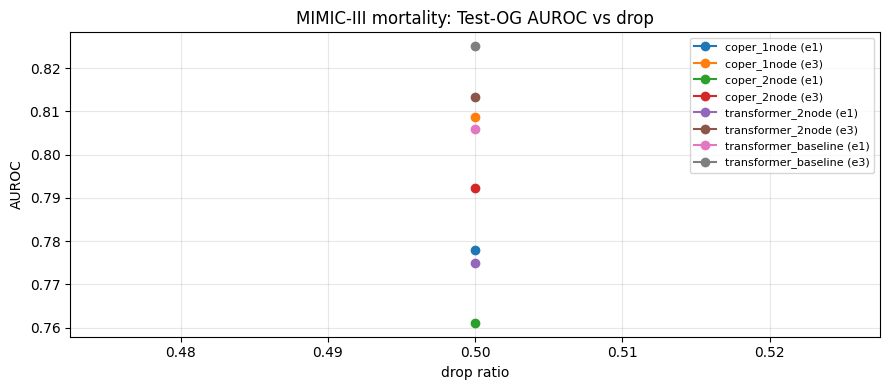

In [13]:
# ---- Plot Test-OG AUROC by drop ----
if 'niters' not in ok.columns:
    plot_df = ok.groupby(['arch_id', 'drop'], as_index=False)['test_og_auroc'].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    for arch_id in plot_df['arch_id'].unique():
        chunk = plot_df[plot_df['arch_id'] == arch_id].sort_values('drop')
        ax.plot(chunk['drop'], chunk['test_og_auroc'], marker='o', label=arch_id)
else:
    plot_df = ok.groupby(['arch_id', 'niters', 'drop'], as_index=False)['test_og_auroc'].mean()
    fig, ax = plt.subplots(figsize=(9, 4))
    for (arch_id, niters), g in plot_df.groupby(['arch_id', 'niters']):
        chunk = g.sort_values('drop')
        ax.plot(
            chunk['drop'],
            chunk['test_og_auroc'],
            marker='o',
            label=f'{arch_id} (e{int(niters)})',
        )

ax.set_title('MIMIC-III mortality: Test-OG AUROC vs drop')
ax.set_xlabel('drop ratio')
ax.set_ylabel('AUROC')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# ---- Export checkpoints to portable bundles (.pt + .json) ----
EXPORT_SCRIPT = BENCH / 'utils' / 'export_coper_checkpoint.py'
ARTIFACTS_DIR = BENCH / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
assert EXPORT_SCRIPT.is_file(), f'Missing export script: {EXPORT_SCRIPT}'

ok_for_export = results_df[(results_df['return_code'] == 0) & (results_df['ckpt_exists'])].copy()
if ok_for_export.empty:
    raise RuntimeError('No successful runs with checkpoint files found for export.')

export_rows = []
for _, row in ok_for_export.iterrows():
    arch_id = row['arch_id']
    repo_dir = Path(row['repo_dir'])
    ckpt_path = Path(row['ckpt_path'])
    seed = int(row['seed'])
    drop = float(row['drop'])
    second_node = bool(row['second_node'])
    model_type = row.get('model_type', 'COPER')
    niters = int(row['niters'])

    export_name = f'{arch_id}_drop{drop:g}_s{seed}_e{niters}'
    cmd = [
        sys.executable,
        str(EXPORT_SCRIPT),
        '--repo', str(repo_dir),
        '--ckpt', str(ckpt_path),
        '--out-dir', str(ARTIFACTS_DIR),
        '--name', export_name,
        '--drop', str(drop),
        '--random-seed', str(seed),
        '--model-type', str(model_type),
    ]
    if second_node:
        cmd.append('--second-node')

    print(f'Exporting {arch_id} (niters={niters}) -> {export_name}')
    proc = subprocess.run(cmd, text=True, capture_output=True, check=False)
    output = (proc.stdout or '') + '\n' + (proc.stderr or '')

    export_rows.append({
        'arch_id': arch_id,
        'architecture': row['architecture'],
        'model_type': model_type,
        'niters': niters,
        'second_node': second_node,
        'seed': seed,
        'drop': drop,
        'ckpt_path': str(ckpt_path),
        'bundle_name': export_name,
        'return_code': proc.returncode,
        'raw_tail': '\n'.join(output.splitlines()[-80:]),
    })

exports_df = pd.DataFrame(export_rows)
failed_exports = exports_df[exports_df['return_code'] != 0]
if not failed_exports.empty:
    display(exports_df)
    raise RuntimeError('Some checkpoint exports failed. Inspect `exports_df["raw_tail"]`.')

exports_df


Exporting coper_1node (niters=1) -> coper_1node_drop0.5_s1_e1
Exporting coper_2node (niters=1) -> coper_2node_drop0.5_s1_e1
Exporting transformer_baseline (niters=1) -> transformer_baseline_drop0.5_s1_e1
Exporting transformer_2node (niters=1) -> transformer_2node_drop0.5_s1_e1
Exporting coper_1node (niters=3) -> coper_1node_drop0.5_s1_e3
Exporting coper_2node (niters=3) -> coper_2node_drop0.5_s1_e3
Exporting transformer_baseline (niters=3) -> transformer_baseline_drop0.5_s1_e3
Exporting transformer_2node (niters=3) -> transformer_2node_drop0.5_s1_e3


,arch_id,architecture,model_type,niters,second_node,seed,drop,ckpt_path,bundle_name,return_code,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),COPER,1,False,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0.5_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,1,True,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0.5_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
2,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,1,False,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_baseline_drop0.5_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
3,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,1,True,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_2node_drop0.5_s1_e1,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
4,coper_1node,1-NODE (ODE → Perceiver),COPER,3,False,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
5,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),COPER,3,True,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
6,transformer_baseline,TRANSFORMER (ODE → T×T self-attention),TRANSFORMER,3,False,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_baseline_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
7,transformer_2node,TRANSFORMER 2-NODE (ODE → T×T self-attention →...,TRANSFORMER,3,True,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,transformer_2node_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...


In [15]:
# ---- Save results to disk ----
tables_dir = RESULTS_ROOT / 'tables'
tables_dir.mkdir(parents=True, exist_ok=True)
results_csv = tables_dir / 'mimic3_repo_comparison_raw.csv'
summary_csv = tables_dir / 'mimic3_repo_comparison_summary.csv'
exports_csv = tables_dir / 'mimic3_repo_export_summary.csv'

results_df.to_csv(results_csv, index=False)
summary.to_csv(summary_csv)
if 'exports_df' in globals():
    exports_df.to_csv(exports_csv, index=False)

print('Saved:', results_csv)
print('Saved:', summary_csv)
if exports_csv.exists():
    print('Saved:', exports_csv)

Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_comparison_raw.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_comparison_summary.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_export_summary.csv
